# 06 - Market Demand and Growth

## Purpose

Understand how HealthSynth models commercial market demand and how that demand ultimately drives prescription generation.

In this notebook, we'll explore:

- what market demand represents
- how market demand differs from market share
- how seasonality influences prescribing volume
- why products can gain prescriptions even while losing market share
- how HealthSynth reconciles market demand with generated prescriptions

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from healthsynth.generator import generate

In [2]:
datasets = generate(
    config_path="../configs/profiles/oncology_training.yaml",
    output_dir="../output/market_demand_analysis",
)

## What is Market Demand?

Market demand represents the total prescribing opportunity within a therapeutic area during a given period.

Unlike market share, which describes how demand is divided among competing products, market demand measures the overall size of the market itself.

HealthSynth estimates monthly market demand by combining configurable baseline demand with growth assumptions and seasonal variation. The resulting demand is then allocated across competing products according to their adjusted market share before being distributed to individual healthcare providers (HCPs).

Understanding market demand is essential because commercial success depends not only on winning market share, but also on participating in markets that may be expanding or contracting over time.

In [3]:
market_demand = datasets["market_demand"]

market_demand.head()

,market_id,month,therapeutic_area,base_market_nrx,growth_factor,seasonality_factor,market_nrx
0,MKT_ONC_CA,2023-01-01,Oncology,700.0,1.000000,0.95,663
1,MKT_ONC_CA,2023-02-01,Oncology,700.0,1.010000,0.98,684
2,MKT_ONC_CA,2023-03-01,Oncology,700.0,1.020100,1.00,739
3,MKT_ONC_CA,2023-04-01,Oncology,700.0,1.030301,1.02,741
4,MKT_ONC_CA,2023-05-01,Oncology,700.0,1.040604,1.03,766


Each row represents the estimated market demand for a therapeutic area during a specific month.

Typical columns include:

| Column | Description |
|---------|-------------|
| therapeutic_area | Therapeutic market being simulated |
| month | Simulation month |
| market_demand | Estimated total prescriptions available |
| growth_rate | Configured market growth assumption |
| seasonal_factor | Seasonal adjustment applied to demand |

The exact columns may vary depending on the simulation profile and HealthSynth version.

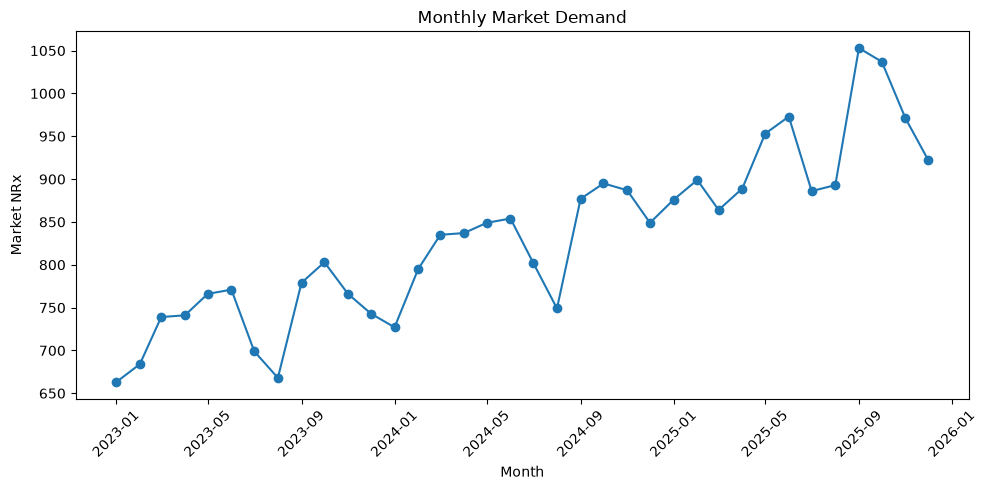

In [5]:
monthly = market_demand.groupby("month")["market_nrx"].sum().reset_index()

monthly["month"] = pd.to_datetime(monthly["month"])

plt.figure(figsize=(10, 5))
plt.plot(
    monthly["month"],
    monthly["market_nrx"],
    marker="o",
)

plt.title("Monthly Market Demand")
plt.xlabel("Month")
plt.ylabel("Market NRx")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Market Demand vs Market Share

Although these terms are often discussed together, they describe different aspects of the commercial landscape.

**Market demand** measures the total number of prescriptions available within a therapeutic area.

**Market share** determines how those prescriptions are divided among competing products.

HealthSynth combines both concepts during simulation:

```
Total Market Demand
        ×
Adjusted Market Share
        ↓
Product Demand
        ↓
Prescription Allocation
```

A product cannot generate prescriptions without market demand, regardless of its market share. Likewise, a growing market can increase prescription volume even if a product's share declines.

### Example

Suppose an oncology market generates **100,000 prescriptions** each month.

Product A holds **40% market share**.

Expected product demand is therefore:

```
100,000 × 40%

=

40,000 prescriptions
```

Now suppose the overall market grows to **120,000 prescriptions**, but Product A's share falls to **35%**.

```
120,000 × 35%

=

42,000 prescriptions
```

Although Product A lost market share, it generated **more prescriptions** because the overall market expanded.

This is why commercial analysts evaluate prescription trends alongside both market demand and market share rather than considering either metric in isolation.

HealthSynth generates prescriptions through a multi-stage commercial simulation.

```
Market Demand
        ×
Adjusted Market Share
        ↓
Product Demand
        ↓
Allocation Across HCPs
        ↓
Generated Prescriptions
```

The final allocation considers several commercial characteristics, including:

- HCP specialty affinity
- Prescribing potential (decile)
- Promotional engagement

This produces realistic variation across healthcare providers while ensuring that total generated prescriptions reconcile with the simulated commercial demand.

In [6]:
products = datasets["product"]
market_share = datasets["market_share"]
prescriptions = datasets["prescriptions"]

> **Business Insight**
>
> Commercial teams often celebrate increasing prescription volume, but prescription growth alone does not necessarily indicate stronger competitive performance.
>
> Analysts must interpret prescription trends alongside market growth and market share. A brand whose prescriptions increase by 5% may actually be losing competitive position if the overall market grew by 15%.

## Key Takeaways

- Market demand represents the total prescribing opportunity within a therapeutic area.
- Market share determines how that opportunity is divided among competing products.
- Growing markets can increase prescriptions even when market share declines.
- HealthSynth models prescriptions as the downstream result of market demand and market share rather than generating them independently.
- Monthly prescription totals reconcile with the commercial demand generated earlier in the simulation.